# Advanced: Constructing realistic clouds with pyradtran

Here, we simulate the irradiance at 15 output altitudes along the flight path of the HALO aircraft during the HALO-(AC)³ campaign. The timesteps are filtered for cloud-free conditions and the simulated albedo is compared to aircraft observations over Arctic sea ice.

In [16]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('config/radiosonde_solar_spectral.yaml')
import logging
# Configure logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


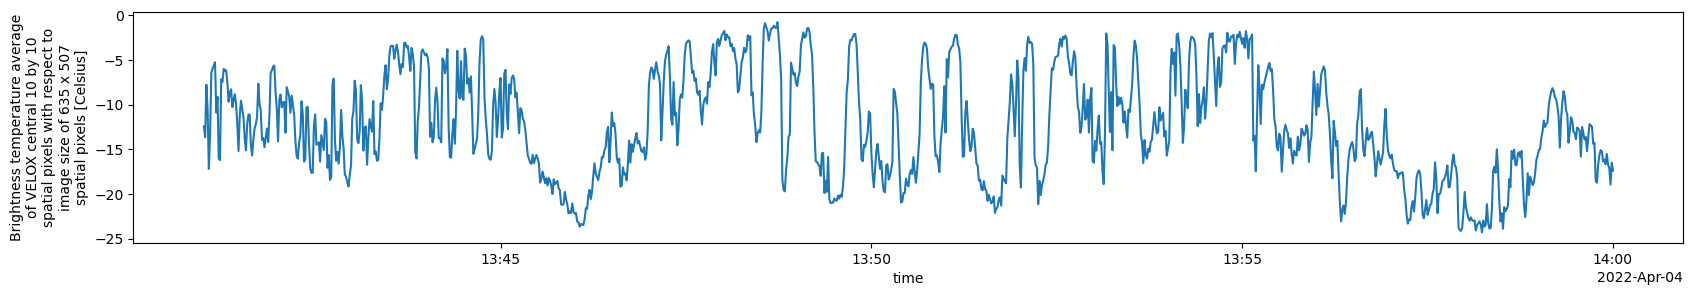

In [2]:
ds = xr.open_dataset('/projekt_agmwend/data/HALO-AC3/02_Flights/HALO-AC3_20220404_HALO_RF13/VELOX/VELOX_327kveL/Processed/to_publish/final/HALO-AC3_HALO_VELOX_BT3_10740nm_20220404_RF13_v3.0.nc').sel(time=slice('2022-04-04T13:41:00', '2022-04-04T14:00:00')).load()

ds.BT_Center.plot(figsize=(20, 3))

In [5]:
ds_specMACS = xr.open_zarr('/projekt_agmwend/data/HALO-AC3/02_Flights/HALO-AC3_20220404_HALO_RF13/specMACS/specMACS_RF13.zarr/').sel(time=slice('2022-04-04T13:41:00', '2022-04-04T14:00:00')).load()

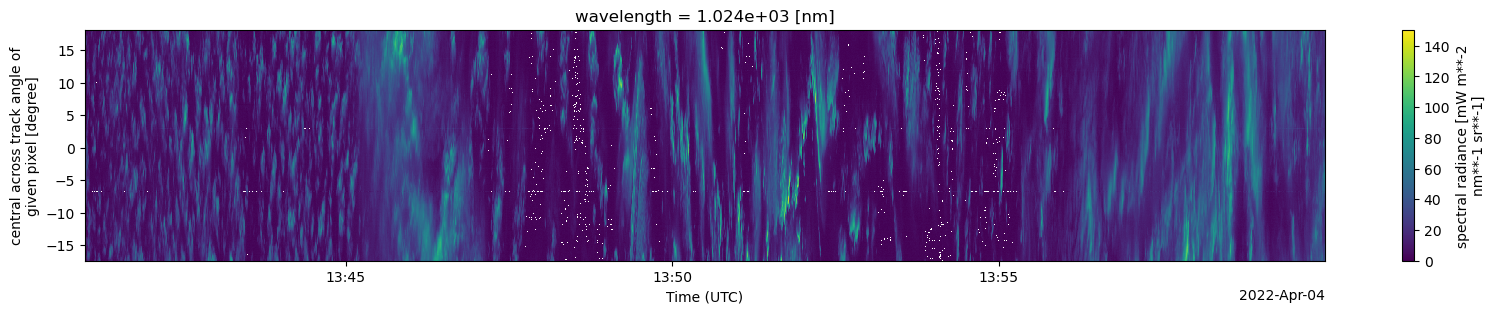

In [11]:
ds_specMACS.radiance.isel(wavelength=0).plot(x='time', figsize=(20, 3))

In [12]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_bt(time):
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))

    bins = np.linspace(-25, 0, 100)
    ds.BT_2D.isel(time=time).plot(cmap='viridis', vmin=-25, vmax=0, ax=ax[1], cbar_kwargs={'label': 'Brightness Temperature (K)'})
    ds.BT_2D.isel(time=time).plot.hist(ax=ax[0], bins=bins, color='gray', alpha=0.7, histtype='step', lw=2)
    plt.tight_layout()
    plt.show()

interact(plot_bt, time=widgets.IntSlider(min=0, max=len(ds.time)-1, step=1, value=240, description='Time Index'));

interactive(children=(IntSlider(value=240, description='Time Index', max=1113), Output()), _dom_classes=('widg…

In [17]:
ds_sel = ds.rename(
    {'lat' : 'latitude', 'lon': 'longitude', 'alt': 'altitude'}
)
ds_sel['altitude_halo'] = ds_sel['altitude'] / 1000 
ds_sel = ds_sel.drop_vars('altitude')
ds_sel['altitude'] = ('altitude', np.arange(0, 15, 0.1))
#s_sel['altitude'] = ds_sel['altitude'] / 1000  # Convert altitude to km


In [18]:
ds_specMACS.wavelength

<xarray.DataArray 'wavelength' (wavelength: 220)> Size: 2kB
array([1024.4 , 1030.74, 1037.08, ..., 2388.16, 2394.41, 2400.67], shape=(220,))
Coordinates:
  * wavelength  (wavelength) float64 2kB 1.024e+03 1.031e+03 ... 2.401e+03
Attributes:
    long_name:  central wavelength of given pixel
    units:      nm

In [22]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
config_path = Path('config/radiosonde_solar_spectral.yaml')

# ds_sim = ds_sel.pyradtran.run_uvspec(
#     config_path=config_path,
#     return_dataset=True,
#     save_to_file=True,
#     output_path='data/Simulated_HALO-AC3_HALO_aircraft_broadband_radiation_clear_sky_with_ocean_600s.nc',
# )

ds_sim_cloud_free = ds_sel.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    # surface_temperature_var='surface_temperature',
    # albedo_var='albedo',
)

print("\nSimulation complete!")
ds_sim_cloud_free

Running batch spectral simulation...


PyRadtranError: All simulations failed - no valid outputs

## Simulation Results

Spectral radiative transfer calculations completed using DISORT solver with multi-level output altitude grid.

In [23]:
# Generate cloud layers using the utility functions
from pyradtran.clouds import CloudLayer, CloudGenerator, CloudFileWriter

# Create simple parametric clouds
simple_clouds = CloudGenerator.from_simple_parameters(
    z_base_km=2.0,
    z_top_km=4.0,
    lwc_g_m3=0.1,
    r_eff_um=10.0,
    n_layers=5
)

# Write custom cloud file
custom_wc_file = Path('work/custom_water_cloud.dat')
CloudFileWriter.write_water_cloud_file(
    cloud_layers=simple_clouds,
    output_path=custom_wc_file,
    altitude_resolution_km=0.1
)

PosixPath('work/custom_water_cloud.dat')

0 NaNs in CTH; 0 NaNs in thickness


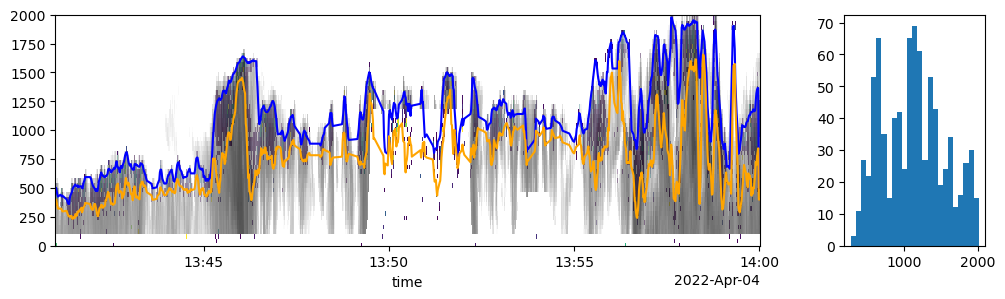

In [24]:
lidar = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bsrgl.nc').sel(time=ds.time).load()
lidar = lidar.where(lidar.backscatter_ratio > 100)
radar = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_radar.nc').sel(time=ds.time).load()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={'width_ratios': [1, .2]})

im_lidar = lidar.backscatter_ratio.where(lidar.backscatter_ratio > 100).plot(y='altitude', robust=True, add_colorbar=False, ax=ax)
im_radar = radar.dBZg.plot(y='height', robust=True, cmap='gray_r', alpha=.7, add_colorbar=False, ax=ax)
ax.set_ylim(0, 2000)

def cth_and_layer_thickness(ds, ds_lidar=lidar):
    """ Calculate cloud top height and layer thickness from lidar data.
    """
    # The lidar data is already filtered for backscatter_ratio > 10
    # We can find the cloud top and base by finding the max and min altitude where the data is not NaN
    
    # Ensure the lidar data is aligned with the ds time, using nearest neighbor interpolation
    ds_lidar_sel = ds_lidar.sel(time=ds.time, method='nearest')
    
    # Find cloud top height (highest altitude with significant backscatter)
    cth = ds_lidar_sel.altitude.where(ds_lidar_sel.backscatter_ratio.notnull()).max(dim='altitude')
    
    # Find cloud base height (lowest altitude with significant backscatter)
    cbh = ds_lidar_sel.altitude.where(ds_lidar_sel.backscatter_ratio.notnull()).min(dim='altitude')

    # if cth is smaller than 150 m, set it to NaN
    cth = cth.where(cth > 150, np.nan)
    cbh = cbh.where(cbh > 150, np.nan)

    
    # Calculate thickness
    thickness = cth - cbh
    # 1d cloudmask
    cloudmask = xr.where((ds_lidar_sel.backscatter_ratio > 100) & (ds_lidar_sel.altitude > 150), 1, 0)

    out_ds = xr.Dataset({
        'cth': cth,
        'thickness': thickness,
        'cloudmask': cloudmask.mean(dim='altitude')  # Mean cloud mask over altitude
    }, coords={
        'time': ds.time,
    })
    return out_ds

cth_ds = cth_and_layer_thickness(ds)
cth_ds = cth_ds.dropna('time')  # Drop times with NaN values
cth = cth_ds.cth
thickness = cth_ds.thickness
cloudmask = cth_ds.cloudmask

cth_interp = cth.rolling(time=5, center=True).mean().interpolate_na('time')
thickness_interp = thickness.rolling(time=5, center=True).mean().interpolate_na('time')
### assign thickness < 100 to 100
thickness_interp = thickness_interp.where(thickness_interp > 100, 100)
thickness_interp = thickness_interp.sel(time=cloudmask > 0)
cth_interp = cth_interp.sel(time=cloudmask > 0)
cth_interp = cth_interp.fillna(500)  # Fill NaNs with 0 for plotting

# print nans
print(f'{cth_interp.isnull().sum().values} NaNs in CTH; {thickness_interp.isnull().sum().values} NaNs in thickness')


cth_interp.plot(ax=ax, label='Cloud Top Height', color='blue')
(cth_interp - thickness_interp).plot(ax=ax, label='Cloud Base Height', color='orange')

lidar_bins = np.linspace(np.nanquantile(lidar.backscatter_ratio, 0.01), np.nanquantile(lidar.backscatter_ratio, 0.99), 50)

#lidar.backscatter_ratio.plot.hist(bins=lidar_bins, color='gray', alpha=0.7, histtype='step', lw=2)
# plot the cloud mask

_= ax2.hist(cth, bins=25)



In [25]:
ds_filtered = ds.sel(time=cth_ds.time)
ds_filtered

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 831, x: 635, y: 507)
Coordinates:
  * time       (time) datetime64[ns] 7kB 2022-04-04T13:41:00 ... 2022-04-04T1...
Dimensions without coordinates: x, y
Data variables:
    lat        (time) float32 3kB 78.3 78.3 78.3 78.3 ... 77.46 77.45 77.45
    lon        (time) float32 3kB -0.5636 -0.5539 -0.5345 ... -0.4079 -0.4165
    alt        (time) float32 3kB 1.064e+04 1.064e+04 ... 1.063e+04 1.063e+04
    yaw        (time) float32 3kB 101.6 101.6 101.7 101.7 ... 240.0 240.0 240.0
    vza        (x, y) float32 1MB 22.06 22.03 22.0 21.97 ... 22.03 22.06 22.09
    vaa        (x, y) float32 1MB 129.0 128.9 128.8 128.7 ... 308.0 308.1 308.2
    BT_2D      (time, x, y) float32 1GB -17.78 -17.7 -17.75 ... -12.11 -11.2
    BT_Center  (time) float32 3kB -12.45 -13.67 -10.61 ... -18.96 -16.51 -17.39
Attributes: (12/21)
    title:                   Two-dimensional cloud-top or surface brightness ...
    research_flight_day:     20220404
    research_flight_number:  RF13
    version:                 Version v3.0 from 2023-09-11
    comment_1:               Band wavelength range: 10.74 +/- 0.39 micrometers
    comment_2:               Flight direction is towards positive y-direction...
    ...                      ...
    institution:             Leipzig University, Leipzig Institute for Meteor...
    author:                  Michael Schäfer, Sophie Rosenburg, André Ehrlich...
    history:                 2023-09-11: First version with destriping, image...
    reference:               Schäfer, M., Wolf, K., Ehrlich, A., Hallbauer, C...
    created_on:              2023-10-20
    Conventions:             "CF-1.8"

In [26]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
config_path = Path('config/radiosonde_thermal.yaml')

# ds_sim = ds_sel.pyradtran.run_uvspec(
#     config_path=config_path,
#     return_dataset=True,
#     save_to_file=True,
#     output_path='data/Simulated_HALO-AC3_HALO_aircraft_broadband_radiation_clear_sky_with_ocean_600s.nc',
# )
logging.getLogger('pyradtran').setLevel(logging.ERROR)
from tqdm import tqdm

ds_sim_cloudy_list = []

for i in tqdm(range(len(ds_filtered.time))):
    # Select the current time slice

    ds_to_sim = ds_filtered.isel(time=[i]).copy().rename(
        {'lat': 'latitude', 'lon': 'longitude'}
    )  # Drop unnecessary variables for simulation
    alt = ds_to_sim.alt / 1e3 # Use mean altitude for the simulation
    #print(f"Selected altitude for simulation: {alt.values} m")
    #ds_to_sim = ds_to_sim.drop_vars(['altitude'])
    ds_to_sim['altitude'] = ('altitude', alt.values)  # Set altitude resolution to 100 m
    cth_i = cth_interp.isel(time=i).values / 1000  # Convert to km
    thickness_i = thickness_interp.isel(time=i).values / 1000  # Convert to km

    #print(f"Simulating time index {i} with CTH={cth_i:.2f} km and thickness={thickness_i:.2f} km")

    # Create simple parametric clouds
    simple_clouds = CloudGenerator.from_simple_parameters(
        z_base_km=cth_i - thickness_i,
        z_top_km=cth_i,
        lwc_g_m3=0.1,
        r_eff_um=10.0,
        n_layers=2
    )

    # Write custom cloud file
    custom_wc_file = Path('work/custom_water_cloud.dat')
    CloudFileWriter.write_water_cloud_file(
        cloud_layers=simple_clouds,
        output_path=custom_wc_file,
        altitude_resolution_km=0.01
    )


    ds_sim_cloudy = ds_to_sim.pyradtran.run_uvspec(
        config_path=config_path,
        return_dataset=True,
        save_to_file=False,
        # surface_temperature_var='surface_temperature',
        # albedo_var='albedo',
        parameter_overrides={
            'output_quantity' : 'brightness',
            'wc_file 1D' : 'custom_water_cloud.dat',  # Use the water cloud file
        },
    )

    ds_sim_cloudy['cloud_top_height'] = cth_i
    ds_sim_cloudy['cloud_thickness'] = thickness_i

    ds_sim_cloudy_list.append(ds_sim_cloudy)

print("\nSimulation complete!")


Running batch spectral simulation...


  0%|          | 0/831 [00:00<?, ?it/s]

100%|██████████| 831/831 [20:45<00:00,  1.50s/it]


Simulation complete!


In [28]:
ds_sim_cloudy

<xarray.Dataset> Size: 60kB
Dimensions:           (time: 831)
Coordinates:
  * time              (time) datetime64[ns] 7kB 2022-04-04T13:41:00 ... 2022-...
    latitude          (time) float32 3kB 78.3 78.3 78.3 ... 77.46 77.45 77.45
    longitude         (time) float32 3kB -0.5636 -0.5539 ... -0.4079 -0.4165
Data variables:
    eup               (time) float64 7kB 262.0 262.0 262.3 ... 255.2 262.0 262.0
    edn               (time) float64 7kB 99.64 99.64 99.64 ... 99.66 99.66 99.66
    edir              (time) float64 7kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    eglo              (time) float64 7kB 99.64 99.64 99.64 ... 99.66 99.66 99.66
    enet              (time) float64 7kB -162.4 -162.4 -162.6 ... -162.4 -162.4
    cloud_top_height  (time) float64 7kB 0.5 0.5 0.4418 0.4257 ... 1.365 0.5 0.5
    cloud_thickness   (time) float64 7kB 0.1 0.1 0.1 0.1044 ... 0.5221 0.1 0.1
Attributes:
    created:                    2025-07-26T00:09:10.276589
    source:                     PyRadtran
    output_type:                integrated_single_altitude
    num_simulations:            1
    is_brightness_temperature:  1
    generated_by:               pyradtran
    pyradtran_version:          new_io_system

In [27]:
ds_sim_cloudy = xr.concat(ds_sim_cloudy_list, dim='time')
ds_sim_cloudy

<xarray.Dataset> Size: 60kB
Dimensions:           (time: 831)
Coordinates:
  * time              (time) datetime64[ns] 7kB 2022-04-04T13:41:00 ... 2022-...
    latitude          (time) float32 3kB 78.3 78.3 78.3 ... 77.46 77.45 77.45
    longitude         (time) float32 3kB -0.5636 -0.5539 ... -0.4079 -0.4165
Data variables:
    eup               (time) float64 7kB 262.0 262.0 262.3 ... 255.2 262.0 262.0
    edn               (time) float64 7kB 99.64 99.64 99.64 ... 99.66 99.66 99.66
    edir              (time) float64 7kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    eglo              (time) float64 7kB 99.64 99.64 99.64 ... 99.66 99.66 99.66
    enet              (time) float64 7kB -162.4 -162.4 -162.6 ... -162.4 -162.4
    cloud_top_height  (time) float64 7kB 0.5 0.5 0.4418 0.4257 ... 1.365 0.5 0.5
    cloud_thickness   (time) float64 7kB 0.1 0.1 0.1 0.1044 ... 0.5221 0.1 0.1
Attributes:
    created:                    2025-07-26T00:09:10.276589
    source:                     PyRadtran
    output_type:                integrated_single_altitude
    num_simulations:            1
    is_brightness_temperature:  1
    generated_by:               pyradtran
    pyradtran_version:          new_io_system

Median brightness temperature: -5.00 K


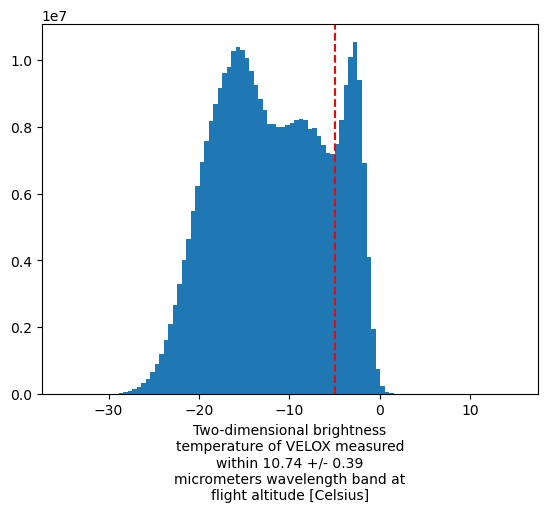

In [19]:
ds.BT_2D.plot.hist(bins=100) 

from scipy.signal import find_peaks

### plot the median brightness temperature for the first 15 time steps
median = ds.BT_2D.quantile(0.5, ['x','y', 'time'])
median = -5
plt.axvline(median, color='red', linestyle='--', label='Median BT')
print(f"Median brightness temperature: {median:.2f} K")

### we use that as a threshold for the brightness temperature to determine the cloud presence
ds_cloudy = ds_filtered.where(ds_filtered.BT_2D < median)

/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_997266/2670785213.py:40: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax_scatter.legend(loc='upper left')
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_997266/2670785213.py:51: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  a.legend()


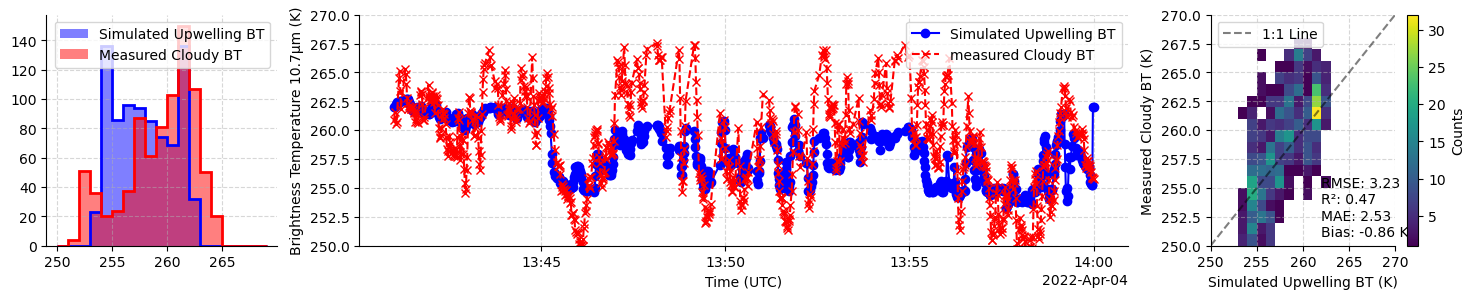

In [37]:
fig, (ax_hists, ax, ax_scatter) = plt.subplots(1, 3, figsize=(18, 3), gridspec_kw={'width_ratios': [.3, 1, .3]})
window = 50  # Define a window size for the scatter plot
y_max = 270
y_min = 250

ds_sim_cloudy.eup.plot(marker='o', color='blue', label='Simulated Upwelling BT', ax=ax)
(ds_cloudy.isel(x=slice(635//2-window, 635//2+window), y=slice(507//2-window, 507//2+window)).BT_2D.mean(['x', 'y']) + 273.15).plot(label='measured Cloudy BT', color='red', linestyle='--', marker='x', ax=ax)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Brightness Temperature 10.7µm (K)')
ax.set_ylim(y_min, y_max)


X = ds_sim_cloudy.eup.values
Y = (ds_cloudy.isel(x=slice(635//2-window, 635//2+window), y=slice(507//2-window, 507//2+window)).BT_2D.mean(['x', 'y']) + 273.15).values
nan_mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[nan_mask]
Y = Y[nan_mask]
bins = np.arange(y_min, y_max, 1)
h = ax_scatter.hist2d(X, Y, label='Simulated Upwelling BT', bins=bins, cmin=1, cmap='viridis')
ax_scatter.set_xlabel('Simulated Upwelling BT (K)')
ax_scatter.set_ylabel('Measured Cloudy BT (K)')
# add a colorbar to the scatter plot
cbar = plt.colorbar(h[3], ax=ax_scatter, label='Counts')

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rmse = np.sqrt(mean_squared_error(X, Y))
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(X, Y)
r2 = r_value**2

mae = mean_absolute_error(X, Y)
bias = np.mean(X - Y)

stats_text = f'RMSE: {rmse:.2f}\nR²: {r2:.2f}\nMAE: {mae:.2f}\nBias: {bias:.2f} K'
ax_scatter.text(0.6, 0.3, stats_text, transform=ax_scatter.transAxes, fontsize=10, verticalalignment='top')
ax_scatter.set_xlim(y_min, y_max)
ax_scatter.set_ylim(y_min, y_max)
ax_scatter.plot([y_min, y_max], [y_min, y_max], color='black', linestyle='--', label='1:1 Line', alpha=0.5)

ax_scatter.legend(loc='upper left')

ax_hists.hist(ds_sim_cloudy.eup.values, bins=bins, color='blue', alpha=0.5, histtype='stepfilled', lw=2, label='Simulated Upwelling BT')
ax_hists.hist(ds_sim_cloudy.eup.values, bins=bins, color='blue', histtype='step', lw=2)

ax_hists.hist((ds_cloudy.BT_2D.mean(['x', 'y']) + 273.15).values, bins=bins, color='red', alpha=0.5, histtype='stepfilled', lw=2, label='Measured Cloudy BT')
ax_hists.hist((ds_cloudy.BT_2D.mean(['x', 'y']) + 273.15).values, bins=bins, color='red', histtype='step', lw=2)

for a in (ax, ax_scatter, ax_hists):
    a.spines[['top', 'right']].set_visible(False)
    a.grid(True, linestyle='--', alpha=0.5)
    a.legend()
    a.set_title('')
    #a.set_ylim(250, 265)